In [73]:
%load_ext autoreload
%autoreload 2

from data_processing import load_and_clean_data, explode_column

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [75]:
sns.set_theme(style="whitegrid")

In [76]:
df = load_and_clean_data('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,1.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,0.0


In [77]:
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,1.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,0.0


In [78]:
display(df.tail())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,12.0
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,1.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,10.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,14.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019.0,4.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8807 non-null   object        
 1   type             8807 non-null   object        
 2   title            8807 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7982 non-null   object        
 5   country          7976 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8807 non-null   int64         
 8   rating           8803 non-null   object        
 9   duration         8804 non-null   object        
 10  listed_in        8807 non-null   object        
 11  description      8807 non-null   object        
 12  year_added       8797 non-null   float64       
 13  wait_time_years  8797 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [80]:
print(f"Le dataset contient {df.shape[0]} observations (lignes) et {df.shape[1]} variables (colonnes).")

Le dataset contient 8807 observations (lignes) et 14 variables (colonnes).


In [81]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'wait_time_years'],
      dtype='object')

In [82]:
df.dtypes

show_id                    object
type                       object
title                      object
director                   object
cast                       object
country                    object
date_added         datetime64[ns]
release_year                int64
rating                     object
duration                   object
listed_in                  object
description                object
year_added                float64
wait_time_years           float64
dtype: object

In [83]:
pourcentage_manquants = (df.isnull().sum() / len(df)) * 100
print(pourcentage_manquants[pourcentage_manquants > 0])

director           29.908028
cast                9.367549
country             9.435676
date_added          0.113546
rating              0.045418
duration            0.034064
year_added          0.113546
wait_time_years     0.113546
dtype: float64


In [84]:
%pip install missingno

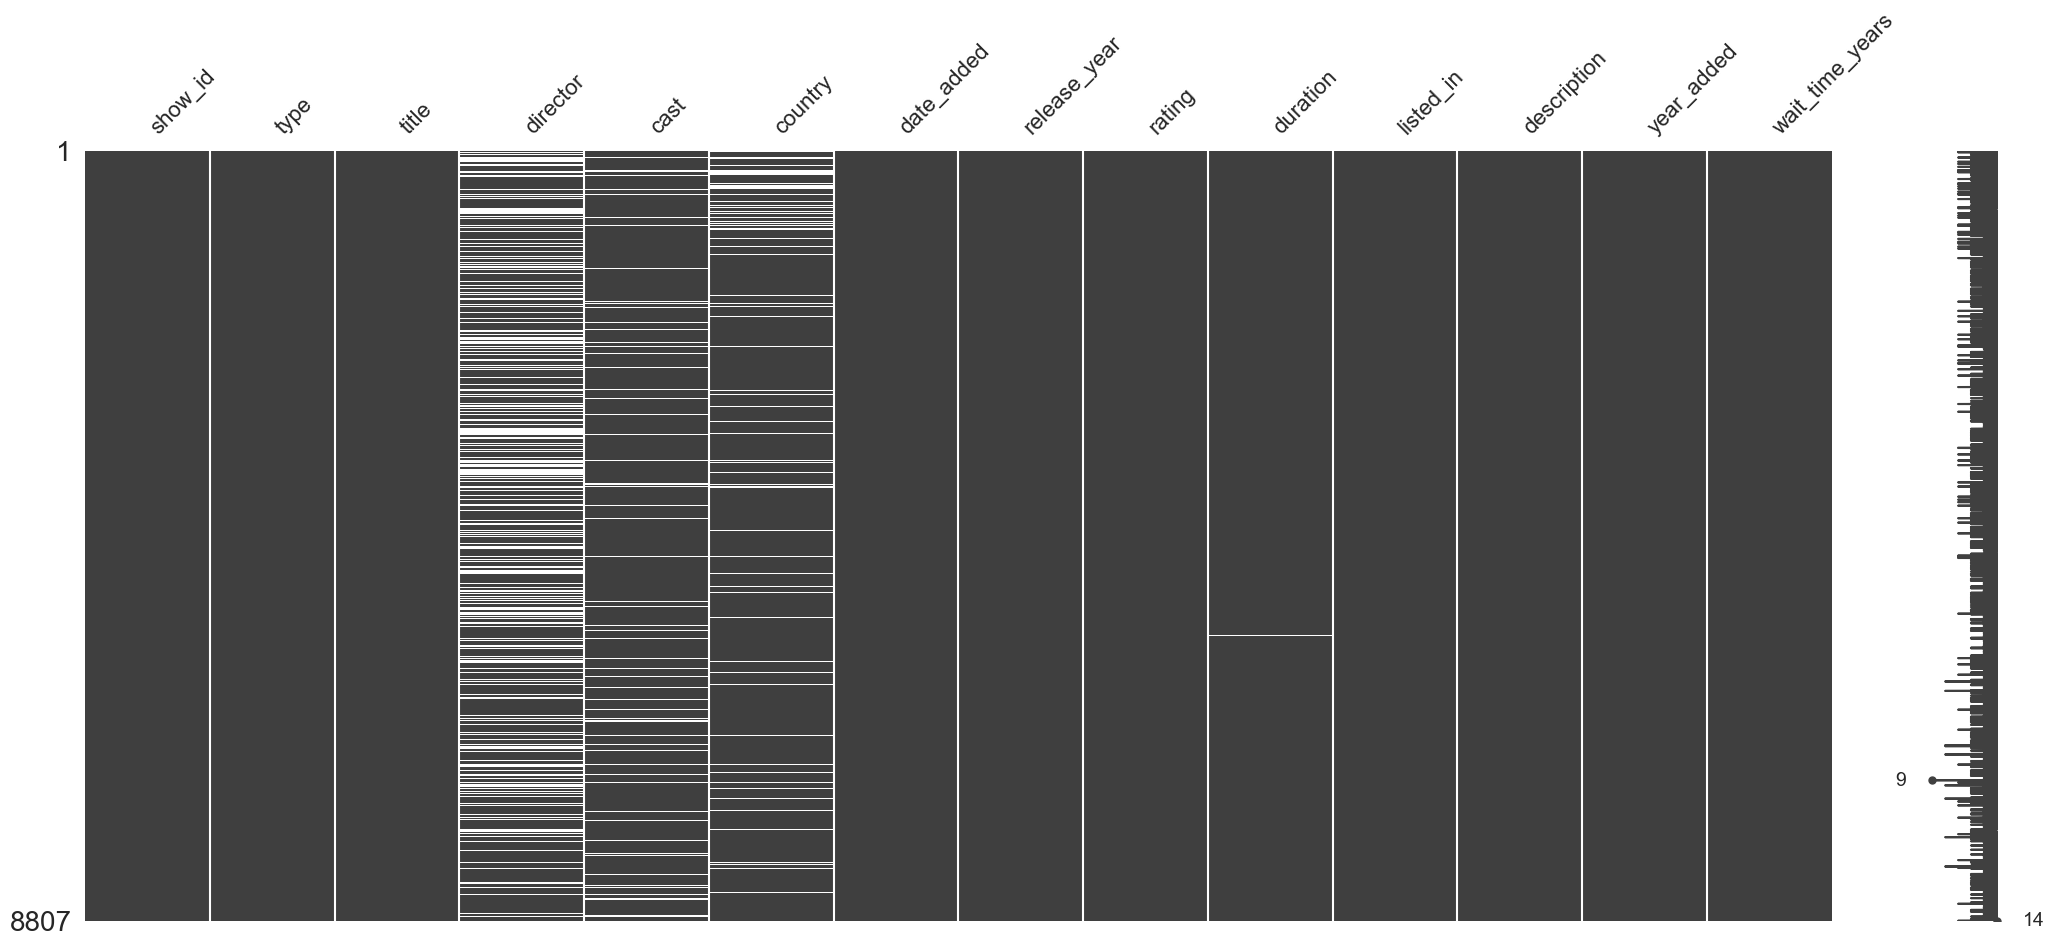

In [85]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [86]:
df.sample(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years
113,s114,Movie,Afterlife of the Party,Stephen Herek,"Victoria Justice, Midori Francis, Robyn Scott,...",NaN,2021-09-02,2021,TV-PG,110 min,"Comedies, Romantic Movies",Cassie lives to party... until she dies in a f...,2021.0,0.0


In [87]:
df[df['title'] == 'Catch Me If You Can']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years
329,s330,Movie,Catch Me If You Can,Steven Spielberg,"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada",2021-08-01,2002,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...,2021.0,19.0


In [88]:
# Film le plus récent (basé sur l'année de sortie)
film_recent = df[df['type'] == 'Movie'].sort_values('release_year', ascending=False).head(1)
print("Film le plus récent :", film_recent['title'].values[0])

# Série la plus récente
serie_recente = df[df['type'] == 'TV Show'].sort_values('release_year', ascending=False).head(1)
print("Série la plus récente :", serie_recente['title'].values[0])

Film le plus récent : My Heroes Were Cowboys
Série la plus récente : Metal Shop Masters


In [89]:
# Film le plus ancien
df['date_added'].dtype

dtype('<M8[ns]')

In [90]:
# Extrait uniquement les suites de chiffres (\d+) de la colonne texte
df['duration'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Vérification
display(df[['type', 'duration']].head())

,type,duration
0,Movie,90.0
1,TV Show,2.0
2,TV Show,1.0
3,TV Show,1.0
4,TV Show,2.0


In [91]:
df['listed_in'] = df['listed_in'].dropna().str.split(', ')
df['listed_in'].head()

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in, dtype: object

In [92]:
for col in ['type', 'country', 'release_year', 'rating']:
    print(f"--- Valeurs uniques pour {col} ---")
    print(df[col].dropna().unique()[:10]) # On limite à 10 pour ne pas inonder l'écran
    print("\n")

--- Valeurs uniques pour type ---
['Movie' 'TV Show']


--- Valeurs uniques pour country ---
['United States' 'South Africa' 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia'
 'United States, India, France']


--- Valeurs uniques pour release_year ---
[2020 2021 1993 2018 1996 1998 1997 2010 2013 2017]


--- Valeurs uniques pour rating ---
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G']




In [93]:
# On compte les apparitions de chaque réalisateur et on affiche ceux qui en ont plus de 1
realisateurs_multiples = df['director'].value_counts()
print(realisateurs_multiples[realisateurs_multiples > 1].head())

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64


In [94]:
# Extraction de l'année d'ajout
df['year_added'] = df['date_added'].dt.year

annee_max_films = df[df['type'] == 'Movie']['year_added'].value_counts().idxmax()
print(f"Année avec le plus de films ajoutés : {int(annee_max_films)}")

annee_max_series = df[df['type'] == 'TV Show']['year_added'].value_counts().idxmax()
print(f"Année avec le plus de séries ajoutées : {int(annee_max_series)}")

Année avec le plus de films ajoutés : 2019
Année avec le plus de séries ajoutées : 2020


In [95]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


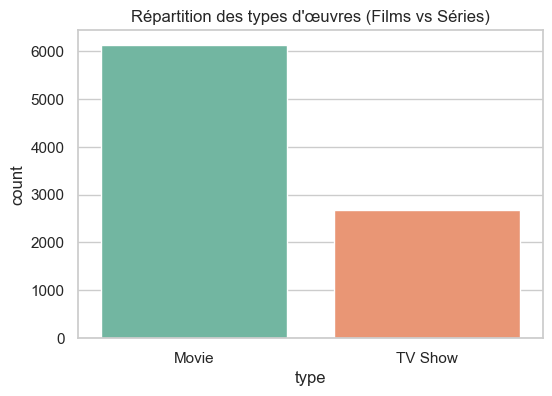

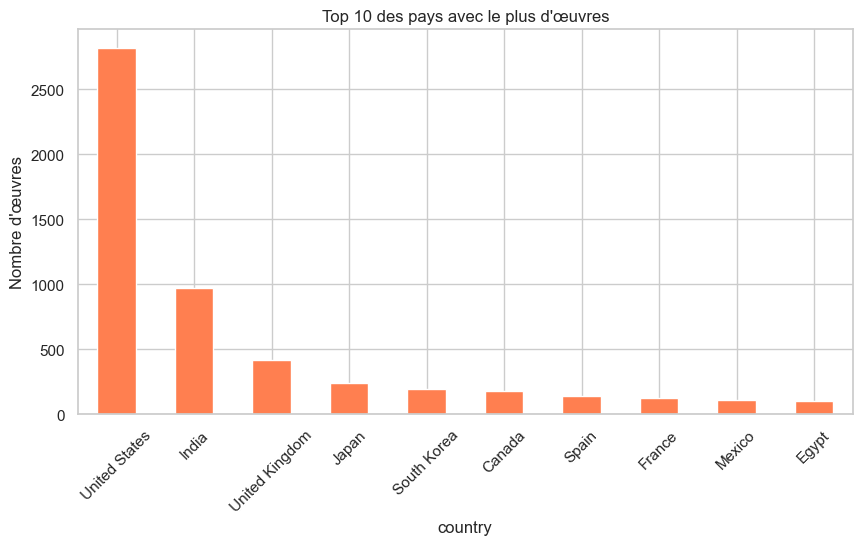

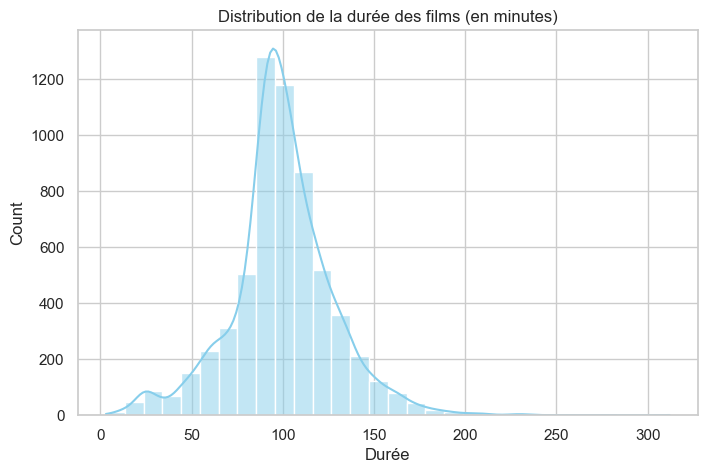

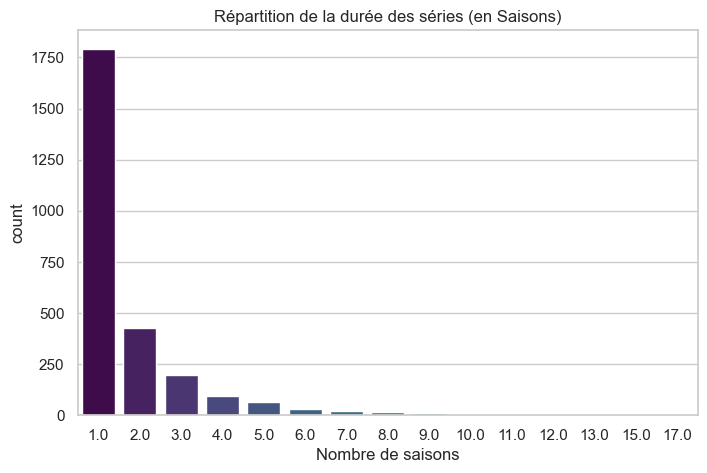

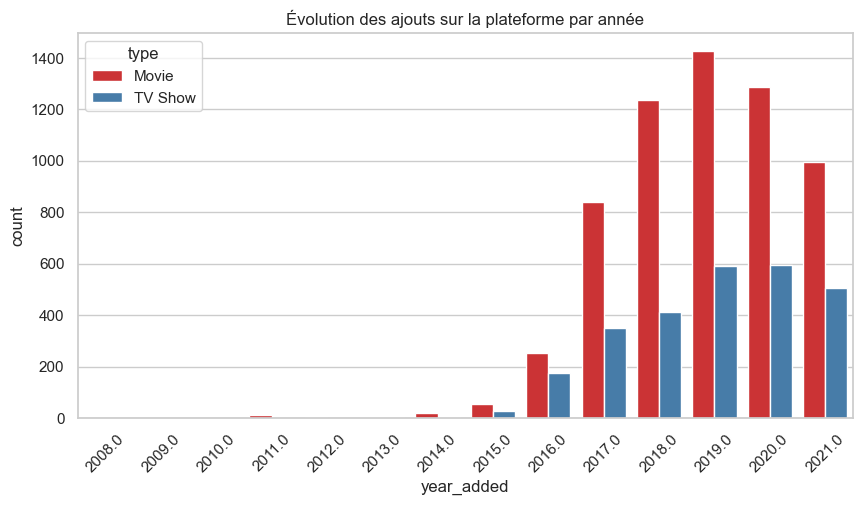

In [96]:
import seaborn as sns

# Configurer le style visuel
sns.set_theme(style="whitegrid")

# a. Répartition du type d'oeuvres
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title("Répartition des types d'œuvres (Films vs Séries)")
plt.savefig('repartition_type.png', bbox_inches='tight')
plt.show()

# b. Top 10 des pays producteurs
plt.figure(figsize=(10, 5))
df['country'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title("Top 10 des pays avec le plus d'œuvres")
plt.ylabel("Nombre d'œuvres")
plt.xticks(rotation=45)
plt.savefig('top-10_pays.png', bbox_inches='tight')
plt.show()

# e. Répartition de la durée des films
plt.figure(figsize=(8, 5))
sns.histplot(df[df['type'] == 'Movie']['duration'], bins=30, kde=True, color='skyblue')
plt.title("Distribution de la durée des films (en minutes)")
plt.xlabel("Durée")
plt.savefig('repartition_duree_films.png', bbox_inches='tight')
plt.show()

# f. Répartition du nombre de saisons des séries
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df['type'] == 'TV Show'], x='duration', hue='duration', palette='viridis', legend=False)
plt.title("Répartition de la durée des séries (en Saisons)")
plt.xlabel("Nombre de saisons")
plt.savefig('repartition_duree_series.png', bbox_inches='tight')
plt.show()

# k. Ajouts au catalogue par année
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='year_added', hue='type', palette='Set1')
plt.title("Évolution des ajouts sur la plateforme par année")
plt.xticks(rotation=45)

# La ligne magique (bbox_inches='tight' évite de rogner les axes)
plt.savefig('evolution_ajouts.png', bbox_inches='tight') 

plt.show()

# 🎬 Mon Analyse des données Netflix

Suite à la création de mes graphiques, voici mes **conclusions principales** :

- Netflix propose beaucoup plus de *Films* que de *Séries*.
- Le pays qui produit le plus de contenu est les **États-Unis**.
- Il y a eu une énorme augmentation des ajouts sur la plateforme à partir de 2018.

C'était mon premier Notebook Jupyter !

## Bonus : Analyse approfondie des genres (Feature Engineering)

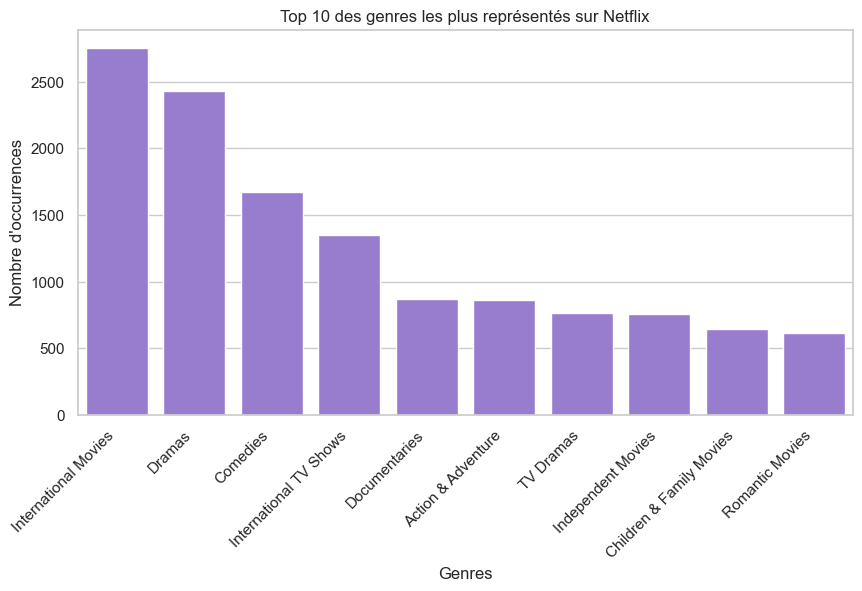

In [97]:
# 0. Chargement de la donnée isolée
df_bonus = load_and_clean_data('netflix_titles.csv')

# 1. Séparation des genres
df_genres = explode_column(df_bonus, 'listed_in', 'genre')

# 2. Comptage
top_genres = df_genres['genre'].value_counts().head(10)

# 3. Affichage robuste avec Seaborn
plt.figure(figsize=(10, 5))
# On utilise sns.barplot au lieu de top_genres.plot()
sns.barplot(x=top_genres.index, y=top_genres.values, color='mediumpurple')

plt.title("Top 10 des genres les plus représentés sur Netflix")
plt.ylabel("Nombre d'occurrences")
plt.xlabel("Genres")
plt.xticks(rotation=45, ha='right')

# Enregistrer la figure avant de l'afficher
plt.savefig('top_genres.png', bbox_inches='tight')

plt.show()

In [100]:
import plotly.express as px

# 1. Préparation des données
df_trend = df_bonus.groupby(['year_added', 'type']).size().reset_index(name='count')

# 2. Création du graphique interactif
fig = px.line(
    df_trend, 
    x='year_added', 
    y='count', 
    color='type',
    # On utilise <br> pour couper le titre, et <sup> pour écrire le sous-titre plus petit
    title="Évolution des ajouts sur Netflix<br><sup>Comparaison entre les Films et les Séries</sup>",
    labels={'year_added': "Année d'ajout", 'count': "Nombre d'œuvres", 'type': "Catégorie"},
    markers=True,
    color_discrete_map={'Movie': '#B1060F', 'TV Show': '#000000'}
)

# 3. Affichage
fig.show()